# `AA Workshop 6` — Coding Challenge

Complete the tasks below to practice implementing regression modeling from `W6_Regression_Advanced.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- implementing linear regression modelling with polynomial features
- implementing L1 & L2 regularization
- evaluating using proper cross-validation

## Task 1 - Predicting Shared Bike Demand in Seoul

You have been provided with a dataset (`SeoulBikeData.csv` in the `data` directory) that contains counts of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information. The dataset is publicly available and you can find further information [here](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand). Your task is to predict the hourly count of shared bikes based on temperature. Do the following:
- Load and inspect the data; perform any clearning steps if necessary.
- Define and create a scatter plot of x and y.
- Perform a train-holdout-test split.
- Train simple, Ridge, and Lasso regression models with polynomial degrees from 1 to 5 and alphas of 0.01, 0.1, 1, 10 (for Ridge and Lasso). Tune hyperparameters based on holdout performance, select the best performing model based on the mean squared error, and calculate final performance on the test set.
- Create a scatter plot of the true values and predictions of the best performing model.

Data Cleaning and Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../data/SeoulBikeData.csv')
display(data.head())
display(data.info())

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

None

In [2]:
# ist doch nicht relevant weil wir nur auf Basis von Temperatur predicten sollen

# display(data['Holiday'].value_counts())
# display(data['Seasons'].value_counts())
# display(data['Functioning Day'].value_counts())

data['Holiday'] = data['Holiday'].map({'No Holiday': 0, 'Holiday': 1})
data['Functioning Day'] = data['Functioning Day'].map({'No': 0, 'Yes': 1})

In [3]:
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')

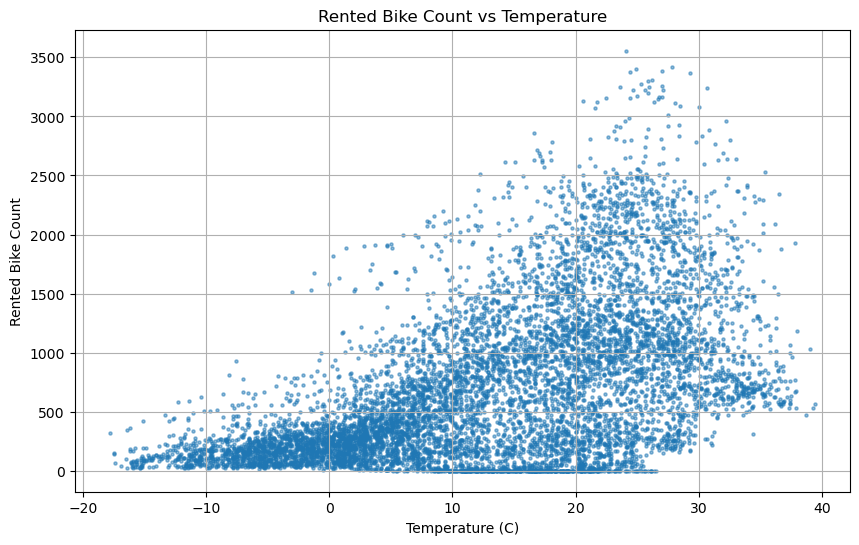

In [4]:
# plot bike count vs temperature and 
plt.figure(figsize=(10,6))
plt.scatter(data['Temperature(C)'], data['Rented Bike Count'], s=5, alpha=0.5)
plt.title('Rented Bike Count vs Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Rented Bike Count')
plt.grid()
plt.show()


In [5]:
(data['Rented Bike Count'] < 0).sum()

np.int64(0)

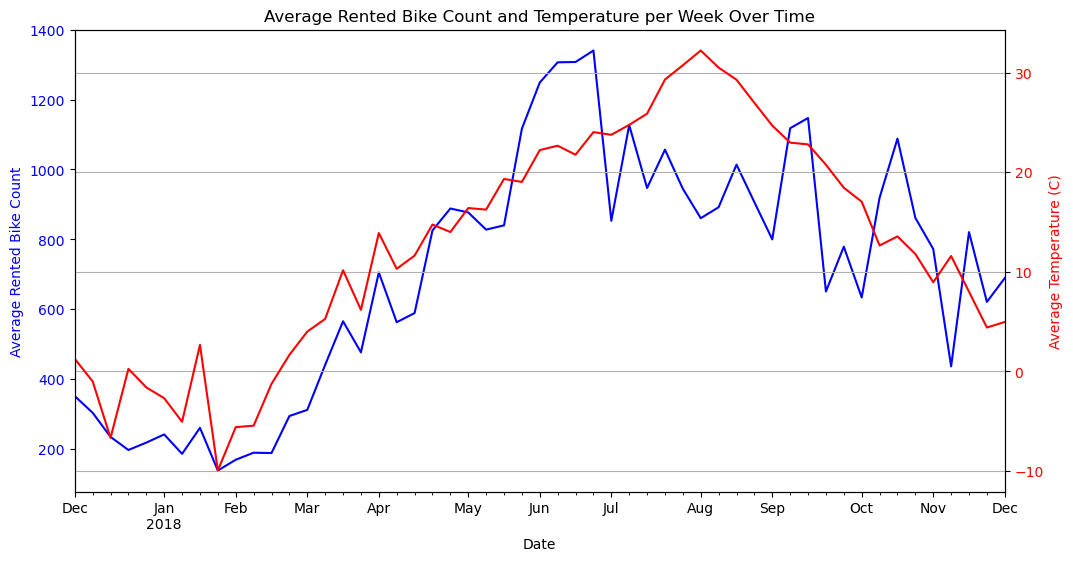

In [6]:
# plotte die Durchschnittliche Anzahl der ausgeliehenen Fahrräder pro Woche im Zeitverlauf
# und füge die durchschnittliche Temperatur pro Woche als zweite Linie hinzu
plt.figure(figsize=(12,6))
ax1 = plt.gca()
data.set_index('Date')['Rented Bike Count'].resample('W').mean().plot(ax=ax1, color='blue', label='Avg Rented Bike Count')
ax1.set_ylabel('Average Rented Bike Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
data.set_index('Date')['Temperature(C)'].resample('W').mean().plot(ax=ax2, color='red', label='Avg Temperature (C)')
ax2.set_ylabel('Average Temperature (C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.title('Average Rented Bike Count and Temperature per Week Over Time')
plt.grid()

Based on the temperature (X) we want to predict the average rented bike count (y)

In [7]:
# test train split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data['Temperature(C)'], data['Rented Bike Count'], test_size=0.3, random_state=42)

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

Train simple, Ridge, and Lasso regression models with polynomial degrees from 1 to 5 and alphas of 0.01, 0.1, 1, 10 (for Ridge and Lasso). Tune hyperparameters based on holdout performance, select the best performing model based on the mean squared error, and calculate final performance on the test set.

In [14]:
for degree in range(1,6):
    # create polynomial features
    Poly = PolynomialFeatures(degree = degree, include_bias=False) # kein Bias term weil Ridge das automatisch hinzufügt
    X_poly_train = Poly.fit_transform(x_train.values.reshape(-1,1)) # train set
    X_poly_test = Poly.fit_transform(x_test.values.reshape(-1,1)) # test set
    
    # scale input features
    scaler = StandardScaler() # sets mean to 0 and variance to 1
    X_poly_train_scaled = scaler.fit_transform(X_poly_train)
    X_poly_test_scaled = scaler.transform(X_poly_test)

    for alpha in [0.1, 1.0, 10.0]:
        # initialize model
        model = Ridge(alpha=alpha)
        model.fit(X_poly_train_scaled, y_train)
        y_pred = model.predict(X_poly_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print(f'Mean Squared Error (Degree {degree}, Alpha {alpha}): {mse}')
        print(f'R^2 Score (Degree {degree}, Alpha {alpha}): {r2}')

Mean Squared Error (Degree 1, Alpha 0.1): 287099.1625982289
R^2 Score (Degree 1, Alpha 0.1): 0.2993994774686838
Mean Squared Error (Degree 1, Alpha 1.0): 287099.1789517146
R^2 Score (Degree 1, Alpha 1.0): 0.2993994375617035
Mean Squared Error (Degree 1, Alpha 10.0): 287099.6318496857
R^2 Score (Degree 1, Alpha 10.0): 0.29939833236671687
Mean Squared Error (Degree 2, Alpha 0.1): 287076.27916226356
R^2 Score (Degree 2, Alpha 0.1): 0.2994553193145796
Mean Squared Error (Degree 2, Alpha 1.0): 287076.2031900625
R^2 Score (Degree 2, Alpha 1.0): 0.29945550470754023
Mean Squared Error (Degree 2, Alpha 10.0): 287076.652416263
R^2 Score (Degree 2, Alpha 10.0): 0.29945440847267857
Mean Squared Error (Degree 3, Alpha 0.1): 281916.37453123706
R^2 Score (Degree 3, Alpha 0.1): 0.3120468986420605
Mean Squared Error (Degree 3, Alpha 1.0): 281908.89002437703
R^2 Score (Degree 3, Alpha 1.0): 0.31206516288696307
Mean Squared Error (Degree 3, Alpha 10.0): 281868.033349277
R^2 Score (Degree 3, Alpha 10.0): 

Create a scatter plot of the true values and predictions of the best performing model.

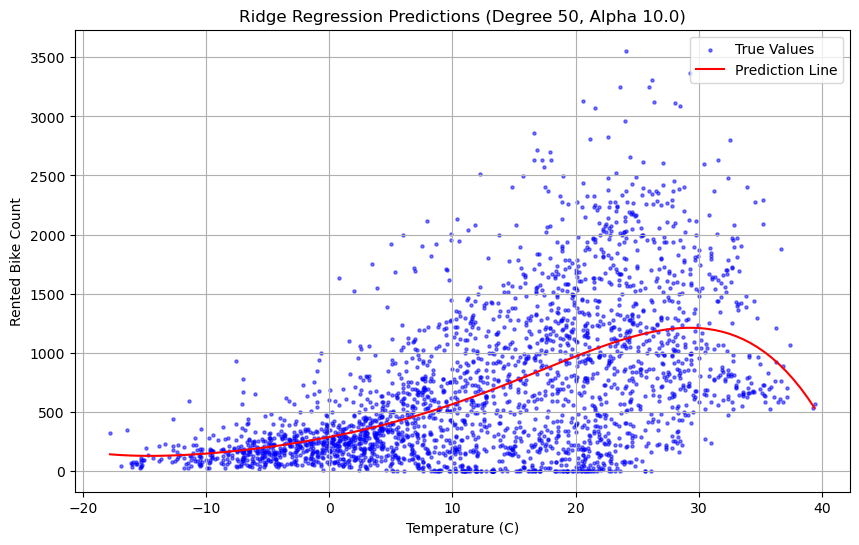

In [ ]:
# Plot ist von der letzten Kombi, nicht der besten
import numpy as np
plt.figure(figsize=(10,6))
plt.scatter(x_test, y_test, color='blue', s=5, alpha=0.5, label='True Values')
# predictions als Linie plotten
x_range = np.linspace(x_test.min(), x_test.max(), 100)
X_range_poly = Poly.fit_transform(x_range.reshape(-1,1))
X_range_poly_scaled = scaler.transform(X_range_poly)
y_range_pred = model.predict(X_range_poly_scaled)
plt.plot(x_range, y_range_pred, color='red', label='Prediction Line')
plt.legend()
plt.title('Ridge Regression Predictions (Degree 50, Alpha 10.0)')
plt.xlabel('Temperature (C)')
plt.ylabel('Rented Bike Count')
plt.grid()
plt.show()

---